<a href="https://colab.research.google.com/github/Bhuvan23-A/nvidia-stock-price-prediction/blob/main/Nvidiastockpricepredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Define the correct column names
col_names = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

# Load the dataset, skipping extra headers
df = pd.read_csv("NVIDIA_STOCK.csv", skiprows=2, names=col_names)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Set 'Date' as index
df.set_index('Date', inplace=True)

# Convert all other columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop any NaN values that may have appeared
df.dropna(inplace=True)

# Display first few rows
print(df.head())
print(df.dtypes)


            Adj Close    Close     High      Low     Open       Volume
Date                                                                  
2018-01-02   4.929880  4.98375  4.98750  4.86250  4.89450  355616000.0
2018-01-03   5.254335  5.31175  5.34250  5.09375  5.10250  914704000.0
2018-01-04   5.282033  5.33975  5.45125  5.31725  5.39400  583268000.0
2018-01-05   5.326794  5.38500  5.42275  5.27700  5.35475  580124000.0
2018-01-08   5.490012  5.55000  5.62500  5.46450  5.51000  881216000.0
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object


/tmp/ipython-input-2196932532.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [3]:
# Checking for missing values
print("Missing Values in Each Column:\n", df.isnull().sum())

# Filling missing values (if any)
df.fillna(method='ffill', inplace=True)

# Display dataset information
df.info()


Missing Values in Each Column:
 Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1697 entries, 2018-01-02 to 2024-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1697 non-null   float64
 1   Close      1697 non-null   float64
 2   High       1697 non-null   float64
 3   Low        1697 non-null   float64
 4   Open       1697 non-null   float64
 5   Volume     1697 non-null   float64
dtypes: float64(6)
memory usage: 92.8 KB


/tmp/ipython-input-4216183047.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [4]:
# Creating Moving Averages
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Creating Daily Return Feature
df['Daily_Return'] = df['Close'].pct_change()

# Creating Volatility Feature (Rolling Standard Deviation)
df['Volatility'] = df['Daily_Return'].rolling(window=10).std()

# Dropping NaN values after feature creation
df.dropna(inplace=True)

# Display first few rows after feature engineering
df.head()


,Adj Close,Close,High,Low,Open,Volume,MA10,MA50,Daily_Return,Volatility
Date,,,,,,,,,,
2018-03-14,6.155107,6.2185,6.26375,6.1555,6.23625,505496000.0,6.052800,5.848435,0.004158,0.019414
2018-03-15,6.169955,6.2335,6.31550,6.1910,6.23225,401952000.0,6.095625,5.873430,0.002412,0.012144
2018-03-16,6.198164,6.2620,6.28125,6.2120,6.25000,399456000.0,6.130475,5.892435,0.004572,0.011467
2018-03-19,5.963581,6.0250,6.23375,5.9250,6.20450,713772000.0,6.143850,5.906140,-0.037847,0.017892
2018-03-20,6.175893,6.2395,6.27875,6.0280,6.02800,554696000.0,6.162400,5.923230,0.035602,0.019267


In [5]:
# Selecting features and target variable
features = ['Open', 'High', 'Low', 'Volume', 'MA10', 'MA50', 'Daily_Return', 'Volatility']
target = 'Close'

# Splitting data into Train (80%) and Test (20%) sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset sizes
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")


Training Set: 1318 samples
Testing Set: 330 samples


In [6]:
# Initializing and training the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)


In [7]:
# Evaluating the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")  # Closer to 1 means better performance


Mean Absolute Error (MAE): 0.26
Root Mean Squared Error (RMSE): 0.50
R² Score: 0.9997


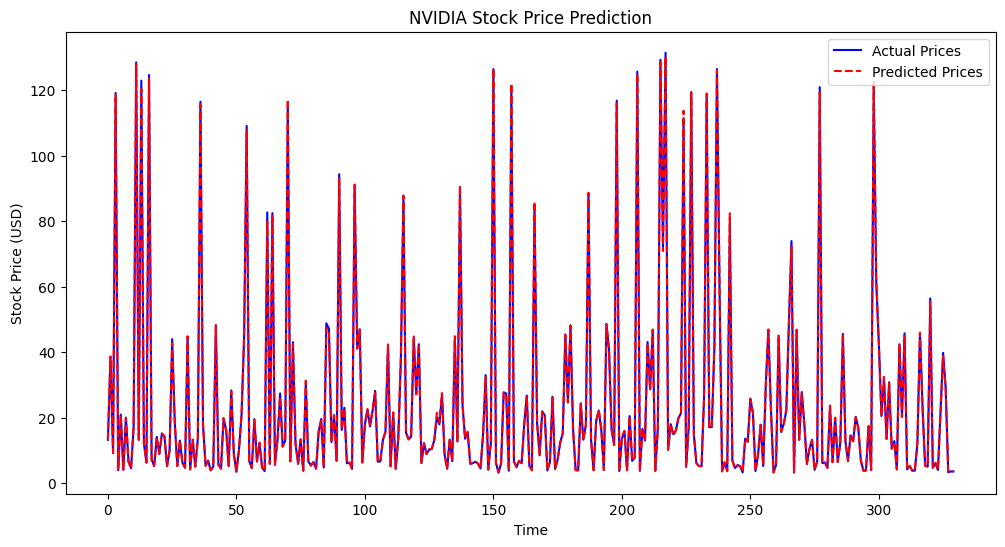

In [8]:
# Plotting Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices', color='red', linestyle='dashed')
plt.title('NVIDIA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()


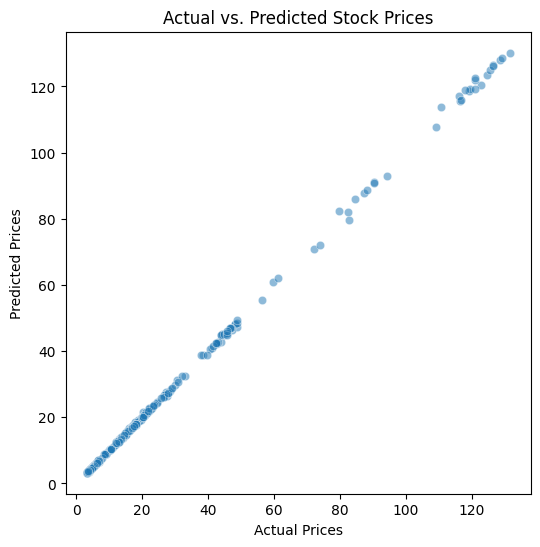

In [9]:
# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Stock Prices")
plt.show()
